In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

import pickle

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("players_22.csv")

In [4]:
df.head()

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


In [5]:
df.shape

(19239, 110)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Columns: 110 entries, sofifa_id to nation_flag_url
dtypes: float64(16), int64(44), object(50)
memory usage: 16.1+ MB


In [7]:
df.describe()

,sofifa_id,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,league_level,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
count,19239.000000,19239.000000,19239.000000,1.916500e+04,19178.000000,19239.000000,19239.000000,19239.000000,19178.000000,19178.000000,...,19239.000000,19239.000000,19239.000000,19239.000000,19239.000000,19239.000000,19239.000000,19239.000000,19239.000000,2132.000000
mean,231468.086959,65.772182,71.079370,2.850452e+06,9017.989363,25.210822,181.299704,74.943032,50580.498123,1.354364,...,57.929830,46.601746,48.045584,45.906700,16.406102,16.192474,16.055356,16.229274,16.491814,36.439962
std,27039.717497,6.880232,6.086213,7.613700e+06,19470.176724,4.748235,6.863179,7.069434,54401.868535,0.747865,...,12.159326,20.200807,21.232718,20.755683,17.574028,16.839528,16.564554,17.059779,17.884833,10.751563
min,41.000000,47.000000,49.000000,9.000000e+03,500.000000,16.000000,155.000000,49.000000,1.000000,1.000000,...,12.000000,4.000000,5.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,15.000000
25%,214413.500000,61.000000,67.000000,4.750000e+05,1000.000000,21.000000,176.000000,70.000000,479.000000,1.000000,...,50.000000,29.000000,28.000000,25.000000,8.000000,8.000000,8.000000,8.000000,8.000000,27.000000
50%,236543.000000,66.000000,71.000000,9.750000e+05,3000.000000,25.000000,181.000000,75.000000,1938.000000,1.000000,...,59.000000,52.000000,56.000000,53.000000,11.000000,11.000000,11.000000,11.000000,11.000000,36.000000
75%,253532.500000,70.000000,75.000000,2.000000e+06,8000.000000,29.000000,186.000000,80.000000,111139.000000,1.000000,...,66.000000,63.000000,65.000000,63.000000,14.000000,14.000000,14.000000,14.000000,14.000000,45.000000
max,264640.000000,93.000000,95.000000,1.940000e+08,350000.000000,54.000000,206.000000,110.000000,115820.000000,5.000000,...,96.000000,93.000000,93.000000,92.000000,91.000000,92.000000,93.000000,92.000000,90.000000,65.000000


In [8]:
df.isnull().sum()

sofifa_id               0
player_url              0
short_name              0
long_name               0
player_positions        0
                    ...  
player_face_url         0
club_logo_url          61
club_flag_url          61
nation_logo_url     18480
nation_flag_url         0
Length: 110, dtype: int64

In [11]:
features = [
    "pace",
    "shooting",
    "passing",
    "dribbling",
    "defending",
    "physic"
]

X = df[features].dropna()

df = df.loc[X.index]

In [12]:
df.shape

(17107, 110)

In [13]:
X.shape

(17107, 6)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

clusters = gmm.fit_predict(
    X_scaled
)

In [16]:
df["Cluster"] = clusters

In [17]:
df["Cluster"].value_counts()

Cluster
2    6115
1    3736
0    3722
3    3534
Name: count, dtype: int64

In [18]:
cluster_summary = (
    df.groupby("Cluster")[features]
    .mean()
)

cluster_summary

,pace,shooting,passing,dribbling,defending,physic
Cluster,,,,,,
0,73.573616,59.327243,62.343901,67.793659,42.265449,57.302794
1,60.671039,32.959315,47.517666,51.236349,64.004818,68.562099
2,67.805233,53.340965,62.229763,65.190025,63.093704,68.698937
3,71.246180,63.763158,53.859932,64.473684,28.930956,62.085173


In [19]:
probabilities = gmm.predict_proba(
    X_scaled
)

probabilities[:5]

array([[9.97042146e-01, 2.00408089e-33, 1.10118891e-17, 2.95785407e-03],
       [5.40531819e-01, 1.18355135e-28, 1.65611363e-11, 4.59468181e-01],
       [9.90665375e-01, 4.51650503e-36, 9.24114906e-17, 9.33462474e-03],
       [9.05115538e-01, 2.53402102e-25, 2.84838059e-14, 9.48844624e-02],
       [9.90685066e-01, 8.79082617e-14, 6.93129601e-03, 2.38363782e-03]])

In [20]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

pca_features = pca.fit_transform(
    X_scaled
)

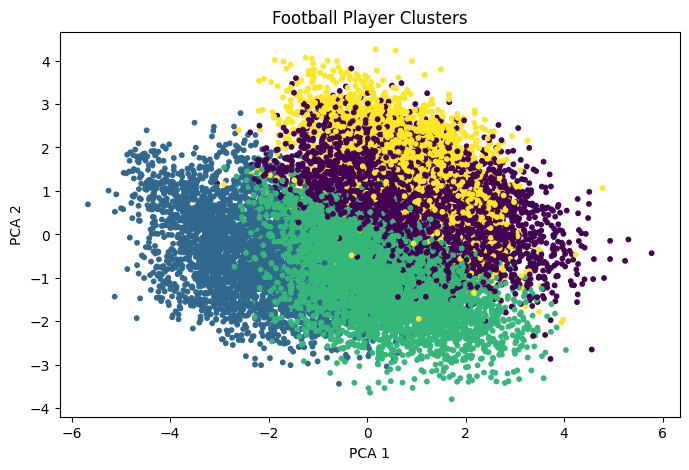

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=df["Cluster"],
    s=10
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Football Player Clusters")

plt.show()

In [22]:
for cluster in sorted(
    df["Cluster"].unique()
):

    print(
        f"\nCluster {cluster}"
    )

    display(
        df[df["Cluster"] == cluster][
            [
                "short_name",
                "player_positions",
                "overall",
                "pace",
                "shooting",
                "passing",
                "dribbling",
                "defending",
                "physic"
            ]
        ].head()
    )


Cluster 0


,short_name,player_positions,overall,pace,shooting,passing,dribbling,defending,physic
0,L. Messi,"RW, ST, CF",93,85.0,92.0,91.0,95.0,34.0,65.0
1,R. Lewandowski,ST,92,78.0,92.0,79.0,86.0,44.0,82.0
2,Cristiano Ronaldo,"ST, LW",91,87.0,94.0,80.0,88.0,34.0,75.0
3,Neymar Jr,"LW, CAM",91,91.0,83.0,86.0,94.0,37.0,63.0
4,K. De Bruyne,"CM, CAM",91,76.0,86.0,93.0,88.0,64.0,78.0



Cluster 1


,short_name,player_positions,overall,pace,shooting,passing,dribbling,defending,physic
46,Rúben Dias,CB,87,61.0,38.0,65.0,68.0,88.0,88.0
47,G. Chiellini,CB,86,68.0,46.0,60.0,59.0,89.0,85.0
56,K. Koulibaly,CB,86,81.0,28.0,51.0,65.0,87.0,85.0
63,A. Laporte,CB,86,63.0,50.0,72.0,69.0,86.0,80.0
68,M. Škriniar,CB,86,80.0,41.0,53.0,69.0,87.0,84.0



Cluster 2


,short_name,player_positions,overall,pace,shooting,passing,dribbling,defending,physic
10,N. Kanté,"CDM, CM",90,78.0,66.0,75.0,82.0,87.0,83.0
14,Casemiro,CDM,89,65.0,73.0,76.0,73.0,86.0,90.0
15,V. van Dijk,CB,89,78.0,60.0,71.0,72.0,91.0,84.0
19,J. Kimmich,"CDM, RB",89,70.0,73.0,86.0,84.0,83.0,79.0
22,Sergio Ramos,CB,88,70.0,70.0,76.0,74.0,88.0,84.0



Cluster 3


,short_name,player_positions,overall,pace,shooting,passing,dribbling,defending,physic
9,H. Kane,ST,90,70.0,91.0,83.0,83.0,47.0,83.0
23,L. Suárez,ST,88,72.0,90.0,82.0,84.0,47.0,83.0
29,E. Haaland,ST,88,89.0,91.0,65.0,80.0,45.0,88.0
30,S. Agüero,ST,87,71.0,89.0,75.0,87.0,33.0,69.0
36,C. Immobile,ST,87,86.0,87.0,67.0,81.0,39.0,77.0


In [23]:
df.to_csv(
    "clustered_players.csv",
    index=False
)

In [24]:
import pickle

pickle.dump(
    gmm,
    open(
        "gmm_model.pkl",
        "wb"
    )
)

In [25]:
pickle.dump(
    scaler,
    open(
        "scaler.pkl",
        "wb"
    )
)